In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [2]:
from ISLP import load_data
boston=load_data("Boston")

In [3]:
# Define features and target
X = boston.drop(columns='medv')
y = boston['medv']

In [4]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
### Ridge regression
ridge = Ridge(alpha=1.0)

# Fit ridge regression to the data with default lambda
ridge.fit(X_scaled, y)

# Ridge coefficients
ridge_coef = ridge.coef_
print(f"Ridge coefficients: {ridge_coef}")

# Sum of squared coefficients (for comparison)
coef_norm = np.sqrt(np.sum(ridge_coef ** 2))
print(f"Sum of squared coefficients: {coef_norm}")


Ridge coefficients: [-1.03473829  1.07879001  0.06910607  0.72390654 -2.1429995   2.57719706
  0.09416456 -3.10870605  2.44768254 -2.07004049 -2.01963584 -3.9237798 ]
Sum of squared coefficients: 7.309021389550337


In [7]:
####################### Split the data into training and testing sets #######################
# Split the data into training and testing sets (50-50 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=8)


In [8]:
# Ridge regression with a specific lambda (alpha=1)
ridge_1 = Ridge(alpha=1)
ridge_1.fit(X_train, y_train)

# Make predictions using the testing set
y_pred_ridge = ridge_1.predict(X_test)

# Calculate the MSE
mse_ridge_1 = mean_squared_error(y_test, y_pred_ridge)
print(f"MSE for Ridge Regression with lambda=1: {mse_ridge_1}")


MSE for Ridge Regression with lambda=1: 26.668868722931297


In [9]:
############################## OLS (Ordinary Least Squares) ##############################

# Fit OLS (Linear Regression) to the training data
ols = LinearRegression()
ols.fit(X_train, y_train)

# Make predictions using the testing set
y_pred_ols = ols.predict(X_test)

# Calculate the MSE for OLS
mse_ols = mean_squared_error(y_test, y_pred_ols)
print(f"MSE for OLS: {mse_ols}")

MSE for OLS: 26.75798490154831


In [10]:
# Perform cross-validation to find the best lambda (alpha) for Ridge regression
alphas = np.logspace(-4, 4, 100)  # Lambda values to test
ridge_cv = Ridge()

# Grid search for the best lambda (alpha) using 5-fold cross-validation
grid_search = GridSearchCV(ridge_cv, param_grid={'alpha': alphas}, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

# Optimal lambda (alpha) from cross-validation
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha from cross-validation: {best_alpha}")


Best alpha from cross-validation: 2.782559402207126


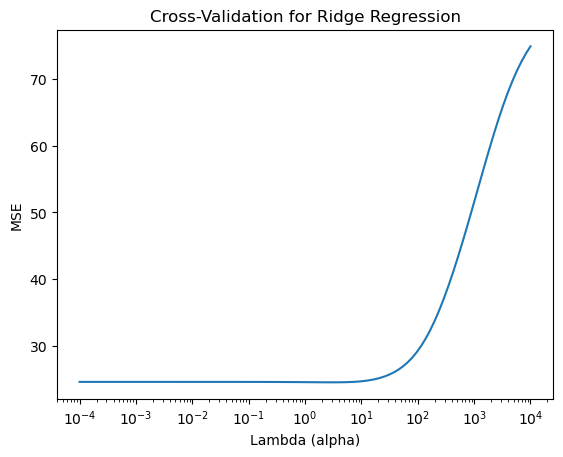

In [11]:
# Plot the cross-validation results
plt.plot(alphas, -grid_search.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('MSE')
plt.title('Cross-Validation for Ridge Regression')
plt.show()


In [12]:
# Refit Ridge model using the best lambda
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train, y_train)

# Make predictions with the best lambda on the testing set
y_pred_ridge_best = ridge_best.predict(X_test)

# Calculate the MSE for the best lambda
mse_ridge_best = mean_squared_error(y_test, y_pred_ridge_best)
print(f"MSE for Ridge Regression with best lambda: {mse_ridge_best}")


MSE for Ridge Regression with best lambda: 26.54140803686398


In [13]:
############################## Ridge regression on full dataset ############################

# Fit Ridge regression on the full dataset with the optimal lambda
ridge_full = Ridge(alpha=best_alpha)
ridge_full.fit(X_scaled, y)

# Get the coefficients of the full model
ridge_full_coef = ridge_full.coef_
print(f"Ridge coefficients for full dataset: {ridge_full_coef}")


Ridge coefficients for full dataset: [-1.02070999  1.05287247  0.03125038  0.72923523 -2.09429047  2.59297508
  0.08179726 -3.06124074  2.33268946 -1.9636955  -2.0058536  -3.89891329]


In [14]:
############################## OLS on full dataset ##########################################

# Fit OLS (Linear Regression) on the full dataset
ols_full = LinearRegression()
ols_full.fit(X_scaled, y)

# Print OLS coefficients
print(f"OLS coefficients for full dataset: {ols_full.coef_}")


OLS coefficients for full dataset: [-1.04309742  1.09422031  0.0923018   0.72062826 -2.17148707  2.56771612
  0.10153691 -3.13599165  2.51742896 -2.13527146 -2.02770102 -3.93810517]


In [15]:
from sklearn.linear_model import Lasso

In [16]:
### Lasso Regression

# Initialize Lasso with a default alpha (regularization strength)
lasso = Lasso(alpha=1)

# Fit the Lasso model to the training data
lasso.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lasso.predict(X_test)

In [17]:
# Calculate the Mean Squared Error (MSE) on the test data
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Display the Lasso coefficients
print(f"Lasso coefficients: {lasso.coef_}")


Mean Squared Error: 30.488778604505374
Lasso coefficients: [-0.06141441  0.         -0.          0.         -0.          2.04966503
 -0.         -0.         -0.         -0.         -1.66479166 -4.0606533 ]


In [18]:
# Use GridSearchCV to find the best alpha (regularization strength)
grid_search = GridSearchCV(Lasso(), param_grid={'alpha': alphas}, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(X_train, y_train)

# Best alpha found by GridSearchCV
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha from cross-validation: {best_alpha}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best alpha from cross-validation: 0.04641588833612782


In [19]:
# Refit the Lasso model with the best alpha
lasso_best = Lasso(alpha=best_alpha)
lasso_best.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best = lasso_best.predict(X_test)

# Calculate the Mean Squared Error (MSE) for the best model
mse_best = mean_squared_error(y_test, y_pred_best)
print(f"Mean Squared Error (best model): {mse_best}")

Mean Squared Error (best model): 26.54047109281416


In [20]:
# Display the Lasso coefficients for the best model
print(f"Lasso coefficients (best model): {lasso_best.coef_}")


Lasso coefficients (best model): [-1.16168809  1.73269012 -0.          0.52676813 -1.39096648  2.07525385
 -0.07020645 -3.14646323  2.20810714 -1.69762693 -2.13866968 -4.52789684]


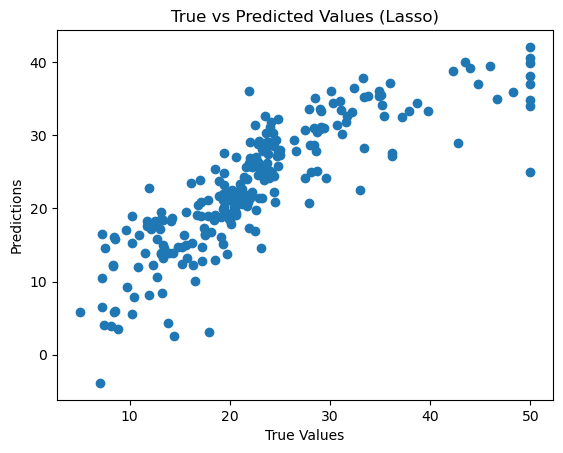

In [22]:
# Visualize the results: Plot the actual vs predicted values
plt.scatter(y_test, y_pred_best)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values (Lasso)")
plt.show()

In [23]:
############################## Lasso regression on full dataset ############################

# Fit Lasso regression on the full dataset with the optimal alpha (lambda)
lasso_full = Lasso(alpha=best_alpha)  # Use the best alpha found in cross-validation
lasso_full.fit(X_scaled, y)

# Get the coefficients of the full model
lasso_full_coef = lasso_full.coef_
print(f"Lasso coefficients for full dataset: {lasso_full_coef}")


Lasso coefficients for full dataset: [-0.90104261  0.90894026 -0.          0.71195542 -1.9062349   2.65568582
  0.         -2.85348632  1.8207261  -1.53733911 -1.95707058 -3.89006788]
